<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_4/Laboratorio%204%20No%20grafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Condori Romero Said — Ing. Sistemas
## Laboratorio 4 — Regresión Logística One-vs-All (Dataset No Gráfico)

# Origen del Dataset

**URL:** https://archive.ics.uci.edu/dataset/325/dataset+for+sensorless+drive+diagnosis

### ¿Qué representa?
Cada fila es una **medición de señal de corriente eléctrica** de un motor con componentes intactos o defectuosos, capturada en dos fases con sonda de corriente y osciloscopio bajo 12 condiciones operativas distintas.


# Objetivo

Clasificar el **estado del motor eléctrico** en una de las **11 condiciones posibles** usando **Regresión Logística Multiclase One-vs-All** con regularización L2.


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize

%matplotlib inline

# Ruta del dataset
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/Sensorless_drive_diagnosis.txt'

# Carga con Pandas (separado por espacios, sin encabezado)
df = pd.read_csv(ruta, sep=' ', header=None)

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (58509, 49)

Primeras filas:


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


## Verificación del Dataset

Se verifica la distribución de clases para asegurarse de que el dataset está balanceado y cumple los requisitos mínimos:
- **m ≥ 50,000** ejemplos
- **n ≥ 40** características

In [ ]:
# Verificar las clases (última columna)
print("Distribución de clases:")
print(df.iloc[:, -1].value_counts().sort_index())

print("\nClases únicas:", sorted(df.iloc[:, -1].unique()))
print("Total de instancias:", len(df))

Distribución de clases:
48
1     5319
2     5319
3     5319
4     5319
5     5319
6     5319
7     5319
8     5319
9     5319
10    5319
11    5319
Name: count, dtype: int64

Clases únicas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Total de instancias: 58509


## Preprocesamiento con Pandas

### Preprocesamiento — Separación X / y

Se separan las **48 características** de la variable objetivo.
Se ajustan las etiquetas de **1-11 → 0-10** porque Python usa indexación base 0 y One-vs-All usa `np.arange(num_labels)` para iterar las clases.

In [ ]:
# ============================================================
# PREPROCESAMIENTO CON PANDAS
# ============================================================

# Separar features (X) y etiquetas (y)
X = df.iloc[:, :-1].values   # primeras 48 columnas
y = df.iloc[:, -1].values    # última columna (clases 1-11)

print("Shape X:", X.shape)   # (58509, 48)
print("Shape y:", y.shape)   # (58509,)

# Ajustar etiquetas: clases 1-11 → 0-10 (indexación desde 0)
y = y - 1
print("Clases únicas después del ajuste:", np.unique(y))

Shape X: (58509, 48)
Shape y: (58509,)
Clases únicas después del ajuste: [ 0  1  2  3  4  5  6  7  8  9 10]


### Preprocesamiento — Normalización Z-score

Las 48 características tienen escalas muy distintas — algunas con valores de orden $10^{-5}$ y otras de orden $10^0$. Sin normalizar, el descenso por el gradiente tardaría mucho más en converger porque las características de mayor magnitud dominarían el cálculo del gradiente.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Se usa `sigma[sigma == 0] = 1` para evitar división por cero en columnas constantes.

In [ ]:
# ============================================================
# NORMALIZACIÓN DE FEATURES
# ============================================================

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
print("Media (primeras 5 features):", mu[:5])
print("Std  (primeras 5 features):", sigma[:5])

Media (primeras 5 features): [-3.33285242e-06  1.43964787e-06  1.41201311e-06 -1.31281493e-06
  1.35123887e-06]
Std  (primeras 5 features): [7.17102387e-05 5.55538117e-05 2.35298883e-04 6.25952081e-05
 5.66089495e-05]


### Preprocesamiento — División 80% Entrenamiento / 20% Prueba

Se dividen los datos en dos conjuntos **mutuamente excluyentes**:
- **80% entrenamiento**: el modelo aprende los parámetros $\theta$ **solo** con estos datos
- **20% prueba**: se reservan como datos no vistos para evaluar la generalización del modelo

Se usa `np.random.seed(42)` para que la división sea **reproducible**.

Si se evaluara con los mismos datos de entrenamiento, el modelo podría memorizar las respuestas y dar 100% sin haber aprendido patrones reales.

In [ ]:
# ============================================================
# SPLIT 80/20 - ENTRENAMIENTO Y PRUEBA
# ============================================================

# Mezclar los datos aleatoriamente (semilla fija para reproducibilidad)
np.random.seed(42)
indices = np.random.permutation(X_norm.shape[0])

# Calcular corte
corte = int(0.8 * X_norm.shape[0])

idx_train = indices[:corte]
idx_test  = indices[corte:]

X_train = X_norm[idx_train]
y_train = y[idx_train]
X_test  = X_norm[idx_test]
y_test  = y[idx_test]

print("Entrenamiento:", X_train.shape, "→", y_train.shape)
print("Prueba:       ", X_test.shape,  "→", y_test.shape)

# Verificar balance en ambos conjuntos
print("\nClases en entrenamiento:")
clases, conteos = np.unique(y_train, return_counts=True)
for c, n in zip(clases, conteos):
    print(f"  Clase {c+1}: {n} ejemplos")

Entrenamiento: (46807, 48) → (46807,)
Prueba:        (11702, 48) → (11702,)

Clases en entrenamiento:
  Clase 1: 4247 ejemplos
  Clase 2: 4261 ejemplos
  Clase 3: 4233 ejemplos
  Clase 4: 4215 ejemplos
  Clase 5: 4242 ejemplos
  Clase 6: 4263 ejemplos
  Clase 7: 4275 ejemplos
  Clase 8: 4260 ejemplos
  Clase 9: 4271 ejemplos
  Clase 10: 4278 ejemplos
  Clase 11: 4262 ejemplos


## Regresión Logística Multiclase

### Función Sigmoidea

La hipótesis de la regresión logística es:

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1+e^{-z}}$$


 Se aplica `np.clip(z, -500, 500)` para evitar overflow en `np.exp`.

In [ ]:
# ============================================================
# FUNCIONES ESTABLES NUMÉRICAMENTE
# ============================================================

def sigmoid(z):
    # Clip evita overflow en exp
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

### Función de Costo Regularizada

La función de costo **regularizada** penaliza valores grandes de $\theta$ (excepto $\theta_0$) para evitar sobreajuste:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2$$

El gradiente con respecto a $\theta_j$:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}(h_\theta(X) - y)^T x_j + \frac{\lambda}{m}\theta_j \quad j \geq 1$$


In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta))

    # Clip evita log(0)
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp = theta.copy()
    temp[0] = 0

    J = (1/m) * np.sum(-y * np.log(h) - (1-y) * np.log(1-h)) \
        + (lambda_ / (2*m)) * np.sum(np.square(temp))

    grad = (1/m) * (h - y).dot(X) + (lambda_/m) * temp

    return J, grad

### Clasificación One-vs-All

Se entrenan **11 clasificadores binarios** — uno por cada condición del motor.
Para la clase $k$, el vector $y$ se convierte en binario:
$$y_j = 1 \text{ si el ejemplo } j \text{ es de la clase } k, \quad y_j = 0 \text{ en caso contrario}$$

Se usa `scipy.optimize.minimize` con el método **CG** (Gradiente Conjugado) para encontrar el $\theta$ óptimo de cada clasificador.

Al finalizar, `all_theta` tiene shape `(11, 49)` — un vector $\theta$ por cada clase.

In [ ]:
# ============================================================
# FUNCIÓN ONE-VS-ALL
# ============================================================

def oneVsAll(X, y, num_labels, lambda_, maxiter=50):
    """
    Entrena num_labels clasificadores de regresion logistica.
    Devuelve all_theta (K x n+1) y cost_history por clase.
    """
    m, n = X.shape
    all_theta   = np.zeros((num_labels, n + 1))
    cost_history = []

    # Agregar termino de intercepcion
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        costs = []

        def cost_wrapper(theta):
            J, grad = lrCostFunction(theta, X_b, (y == c), lambda_)
            costs.append(J)
            return J, grad

        res = optimize.minimize(
            cost_wrapper,
            initial_theta,
            method='CG',
            jac=True,
            options={'maxiter': maxiter}
        )

        all_theta[c]  = res.x
        cost_history.append(costs)
        print('Clase {:2d} entrenada — costo final: {:.6f}'.format(c, costs[-1] if costs else 0))

    return all_theta, cost_history


### Entrenamiento del Modelo

Se entrena el modelo con `lambda_ = 0.1` y `maxiter = 50` sobre el **80% de entrenamiento**.

In [ ]:
# ============================================================
# PARÁMETROS Y ENTRENAMIENTO
# ============================================================

num_labels = 11
lambda_    = 0.1
maxiter    = 50

print('Iniciando entrenamiento One-vs-All...')
print(f'  {num_labels} clasificadores | lambda={lambda_} | maxiter={maxiter}\n')

all_theta, cost_history = oneVsAll(X_train, y_train, num_labels, lambda_, maxiter)

print(f'\nShape all_theta: {all_theta.shape}')


Iniciando entrenamiento One-vs-All...
  11 clasificadores | lambda=0.1 | maxiter=50

Clase  0 entrenada — costo final: 0.051574
Clase  1 entrenada — costo final: 0.237551
Clase  2 entrenada — costo final: 0.276881
Clase  3 entrenada — costo final: 0.192918
Clase  4 entrenada — costo final: 0.245040
Clase  5 entrenada — costo final: 0.224381
Clase  6 entrenada — costo final: 0.001037
Clase  7 entrenada — costo final: 0.191190
Clase  8 entrenada — costo final: 0.247076
Clase  9 entrenada — costo final: 0.168993
Clase 10 entrenada — costo final: 0.000042

Shape all_theta: (11, 49)


In [ ]:
print(all_theta)


[[-1.35710717e+01  1.12826853e+00  2.56024839e-01  2.61485792e-01
   4.46406739e+00  1.03058374e+00  1.77348495e-01  5.85189067e+00
   5.85183407e+00  5.84946466e+00 -5.15581383e+00 -5.15681611e+00
  -5.15754875e+00  2.36983473e+00  1.56739173e+00  2.45287585e-01
  -3.43939006e+00  1.97639424e-01 -3.28069676e-02 -3.69194675e-01
  -3.71092155e-01 -3.70303556e-01  1.45874854e-01  1.45890985e-01
   1.47981945e-01 -2.94002507e-01 -4.58989251e-02 -5.47533945e-02
  -9.14585123e-01 -2.15841155e-01 -8.67574248e-02 -5.01616033e-01
  -2.24512113e-01  4.12497865e-01  7.04240852e-01  8.19571594e-01
   8.92555661e-01 -1.59503786e+00 -8.87594804e-02 -1.54380179e-01
  -2.40288922e+00 -7.28255018e-02 -4.15730652e-02  1.90213758e-01
  -1.64076670e-02 -6.96000857e-01 -2.48154443e-01 -1.88046942e-01
   3.72885544e-01]
 [-3.03337489e+00  5.75174241e-01  5.89980994e-01  6.27287323e-02
  -1.58659589e+00  9.40594712e-01  1.01481183e-01 -5.77207099e-01
  -5.78105115e-01 -5.78508992e-01  4.98871692e-01  4.9803

## Predicción y Evaluación

### Función de Predicción One-vs-All

Para cada ejemplo se calculan las **11 probabilidades** y se selecciona la clase con mayor valor:



In [ ]:
# ============================================================
# PREDICCIÓN
# ============================================================

def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X_b.dot(all_theta.T)), axis=1)
    return p

# PREDICCIÓN Y PRECISIÓN
pred_train = predictOneVsAll(all_theta, X_train)
pred_test  = predictOneVsAll(all_theta, X_test)

acc_train = np.mean(pred_train == y_train) * 100
acc_test  = np.mean(pred_test  == y_test)  * 100

print(f"Precisión entrenamiento : {acc_train:.2f}%")
print(f"Precisión prueba        : {acc_test:.2f}%")

Precisión entrenamiento : 74.71%
Precisión prueba        : 74.19%


### Curvas de Convergencia del Costo por Clasificador

Se visualiza cómo disminuye el costo $J(\theta)$ en cada iteración para los 11 clasificadores.


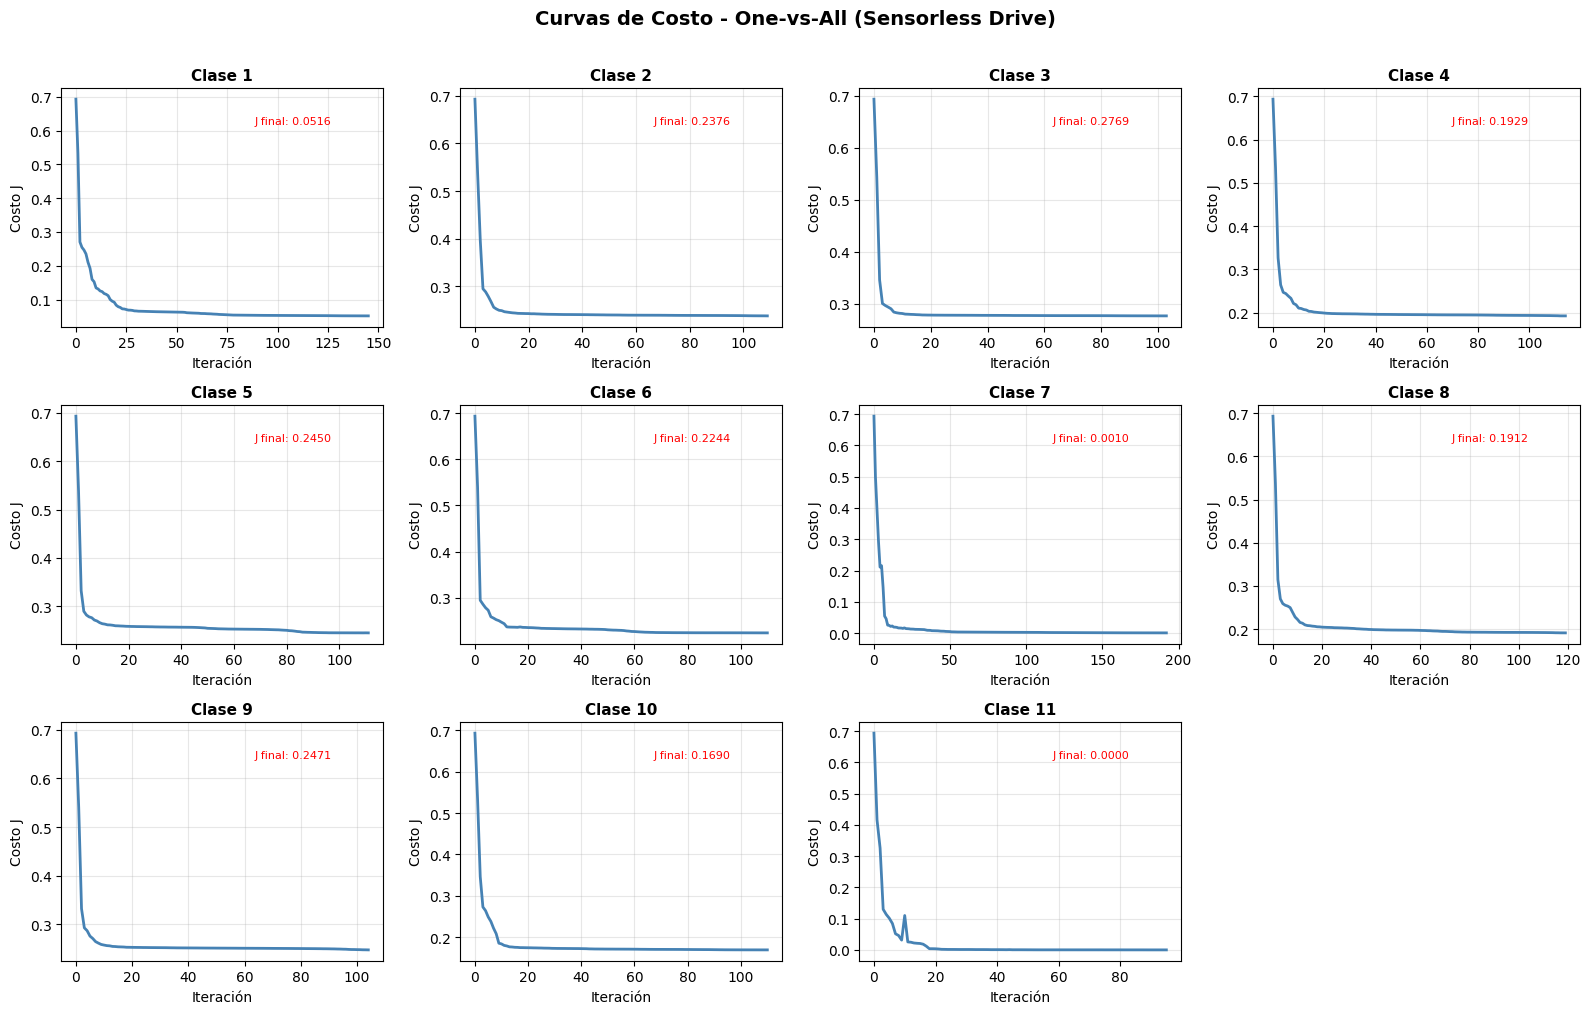

In [ ]:
# ============================================================
# GRÁFICA 1: COSTO POR CLASIFICADOR
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for c in range(num_labels):
    axes[c].plot(cost_history[c], color='steelblue', linewidth=2)
    axes[c].set_title(f'Clase {c+1}', fontsize=11, fontweight='bold')
    axes[c].set_xlabel('Iteración')
    axes[c].set_ylabel('Costo J')
    axes[c].grid(True, alpha=0.3)
    # Costo inicial y final
    if len(cost_history[c]) > 0:
        axes[c].annotate(f"J final: {cost_history[c][-1]:.4f}",
                        xy=(0.6, 0.85), xycoords='axes fraction', fontsize=8,
                        color='red')

# Ocultar el subplot extra (posición 12)
axes[11].set_visible(False)

plt.suptitle('Curvas de Costo - One-vs-All (Sensorless Drive)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('costo_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### Precisión por Clase — Entrenamiento vs Prueba

Se compara la precisión binaria de cada clasificador en entrenamiento y prueba.
Si ambas barras son similares el modelo generaliza bien.
Una diferencia grande indica sobreajuste (el modelo memoriza el entrenamiento).

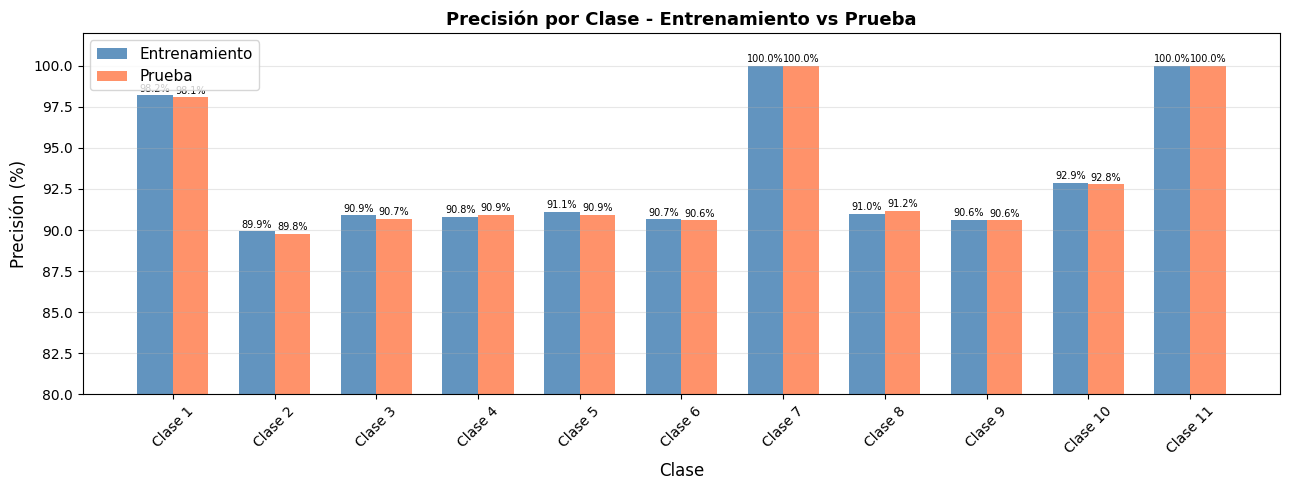

In [ ]:
# ============================================================
# GRÁFICA 2: PRECISIÓN TRAIN VS TEST POR CLASE
# ============================================================

precisiones_train = []
precisiones_test  = []

X_train_b = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test_b  = np.concatenate([np.ones((X_test.shape[0],  1)), X_test],  axis=1)

for c in range(num_labels):
    theta_c = all_theta[c]

    # Predicción binaria para clase c
    p_train = (sigmoid(X_train_b.dot(theta_c)) >= 0.5).astype(int)
    p_test  = (sigmoid(X_test_b.dot(theta_c))  >= 0.5).astype(int)

    acc_tr = np.mean(p_train == (y_train == c).astype(int)) * 100
    acc_te = np.mean(p_test  == (y_test  == c).astype(int)) * 100

    precisiones_train.append(acc_tr)
    precisiones_test.append(acc_te)

x_pos = np.arange(num_labels)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x_pos - width/2, precisiones_train, width,
               label='Entrenamiento', color='steelblue', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, precisiones_test,  width,
               label='Prueba',        color='coral',     alpha=0.85)

ax.set_xlabel('Clase', fontsize=12)
ax.set_ylabel('Precisión (%)', fontsize=12)
ax.set_title('Precisión por Clase - Entrenamiento vs Prueba',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Clase {i+1}' for i in range(num_labels)], rotation=45)
ax.set_ylim(80, 102)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Etiquetas sobre las barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('precision_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### Matriz de Confusión



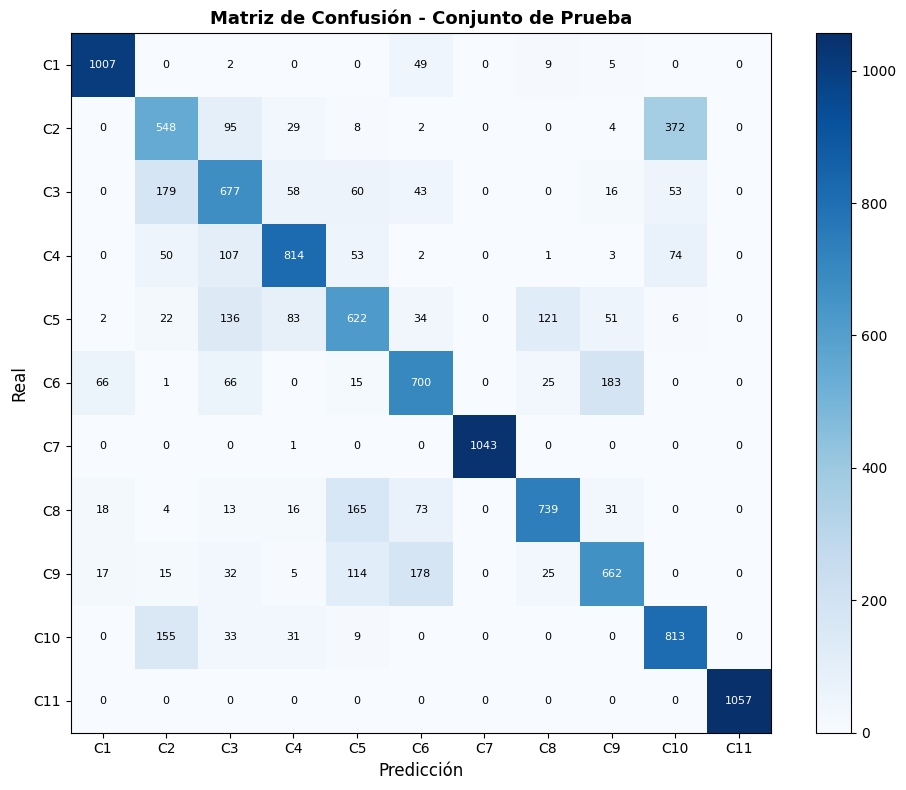

In [ ]:
# ============================================================
# GRÁFICA 3: MATRIZ DE CONFUSIÓN
# ============================================================

# Construir matriz manualmente
conf_matrix = np.zeros((num_labels, num_labels), dtype=int)
for real, pred in zip(y_test, pred_test):
    conf_matrix[int(real)][int(pred)] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(np.arange(num_labels))
ax.set_yticks(np.arange(num_labels))
ax.set_xticklabels([f'C{i+1}' for i in range(num_labels)])
ax.set_yticklabels([f'C{i+1}' for i in range(num_labels)])
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión - Conjunto de Prueba',
             fontsize=13, fontweight='bold')

# Valores dentro de la matriz
thresh = conf_matrix.max() / 2
for i in range(num_labels):
    for j in range(num_labels):
        ax.text(j, i, str(conf_matrix[i, j]), ha='center', va='center',
                color='white' if conf_matrix[i, j] > thresh else 'black',
                fontsize=8)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

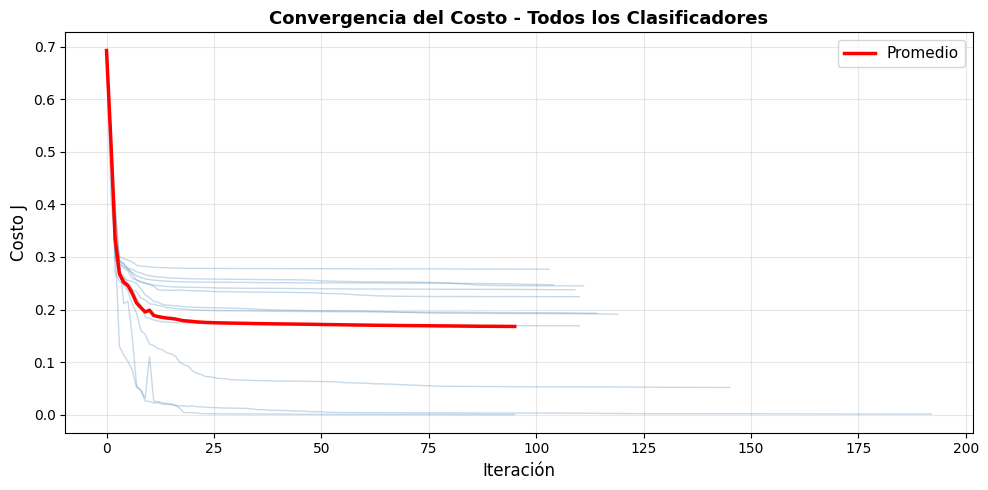

In [ ]:
# ============================================================
# GRÁFICA 4: COSTO PROMEDIO POR ITERACIÓN (todos los clasificadores)
# ============================================================

# Encontrar la longitud mínima de iteraciones entre todos los clasificadores
min_len = min(len(c) for c in cost_history)
costs_array = np.array([c[:min_len] for c in cost_history])
costo_promedio = np.mean(costs_array, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
for c in range(num_labels):
    ax.plot(cost_history[c], alpha=0.3, linewidth=1, color='steelblue')

ax.plot(costo_promedio, color='red', linewidth=2.5, label='Promedio', zorder=5)
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('Costo J', fontsize=12)
ax.set_title('Convergencia del Costo - Todos los Clasificadores',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('costo_promedio.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# RESUMEN FINAL
# ============================================================

print("=" * 45)
print("      RESUMEN DEL MODELO")
print("=" * 45)
print(f"  Dataset        : Sensorless Drive Diagnosis")
print(f"  Instancias     : 58,509  (48 features)")
print(f"  Clases         : 11")
print(f"  Train/Test     : 80% / 20%")
print(f"  Lambda         : {lambda_}")
print(f"  Max iteraciones: {maxiter}")
print("-" * 45)
print(f"  Precisión Train: {acc_train:.2f}%")
print(f"  Precisión Test : {acc_test:.2f}%")
print(f"  Diferencia     : {abs(acc_train - acc_test):.2f}%")
print("=" * 45)


      RESUMEN DEL MODELO
  Dataset        : Sensorless Drive Diagnosis
  Instancias     : 58,509  (48 features)
  Clases         : 11
  Train/Test     : 80% / 20%
  Lambda         : 0.1
  Max iteraciones: 50
---------------------------------------------
  Precisión Train: 74.71%
  Precisión Test : 74.19%
  Diferencia     : 0.51%
